# Tutorial 3: Core Spatial Analysis

**Duration:** 15-20 minutes

This tutorial covers fundamental spatial operations that form the foundation of tissue analysis. You'll learn how to compute distances, find neighbors, and identify spatial clusters.

## Learning Objectives

By the end of this tutorial, you will be able to:
- Build KD-trees for efficient spatial queries
- Compute pairwise distances and nearest neighbor queries
- Analyze distances between specific cell types
- Apply spatial clustering algorithms (DBSCAN, k-means)
- Identify connected spatial regions

## Prerequisites

- Tutorial 1 (Quickstart) completed
- Tutorial 2 (Data Loading) completed
- Basic understanding of distance metrics

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import spatialtissuepy
from spatialtissuepy import SpatialTissueData
from spatialtissuepy.spatial import (
    # Distance operations
    build_kdtree,
    pairwise_distances,
    nearest_neighbors,
    radius_neighbors,
    mean_nearest_neighbor_distance,
    distance_to_type,
    distance_to_nearest_different_type,
    # Geometry
    centroid,
    centroid_by_type,
    bounding_box,
    point_density,
    # Clustering
    dbscan_clustering,
    kmeans_spatial,
    cluster_statistics,
    connected_components_spatial,
)
from spatialtissuepy.viz import plot_spatial_scatter

# Set random seed for reproducibility
np.random.seed(42)

### Create sample tissue data

We'll create a synthetic tissue with distinct spatial patterns:

In [2]:
# Create tumor cells (clustered in center)
tumor_coords = np.random.normal(loc=[500, 500], scale=100, size=(200, 2))
tumor_types = np.array(['Tumor'] * 200)

# Create T cells (scattered, slightly more near tumor)
tcell_coords_near = np.random.normal(loc=[500, 500], scale=200, size=(100, 2))
tcell_coords_far = np.random.uniform(low=0, high=1000, size=(50, 2))
tcell_coords = np.vstack([tcell_coords_near, tcell_coords_far])
tcell_types = np.array(['T_cell'] * 150)

# Create macrophages (clustered in corner)
macro_coords = np.random.normal(loc=[200, 800], scale=80, size=(75, 2))
macro_types = np.array(['Macrophage'] * 75)

# Create fibroblasts (uniformly scattered)
fibro_coords = np.random.uniform(low=0, high=1000, size=(100, 2))
fibro_types = np.array(['Fibroblast'] * 100)

# Combine all cells
coordinates = np.vstack([tumor_coords, tcell_coords, macro_coords, fibro_coords])
cell_types = np.concatenate([tumor_types, tcell_types, macro_types, fibro_types])

# Create SpatialTissueData object
tissue = SpatialTissueData(coordinates=coordinates, cell_types=cell_types)
print(tissue)

SpatialTissueData
  Cells: 525
  Dimensions: 2D
  Cell types: 4
  Bounds: x=[5.7, 1115.8], y=[4.6, 1010.6]


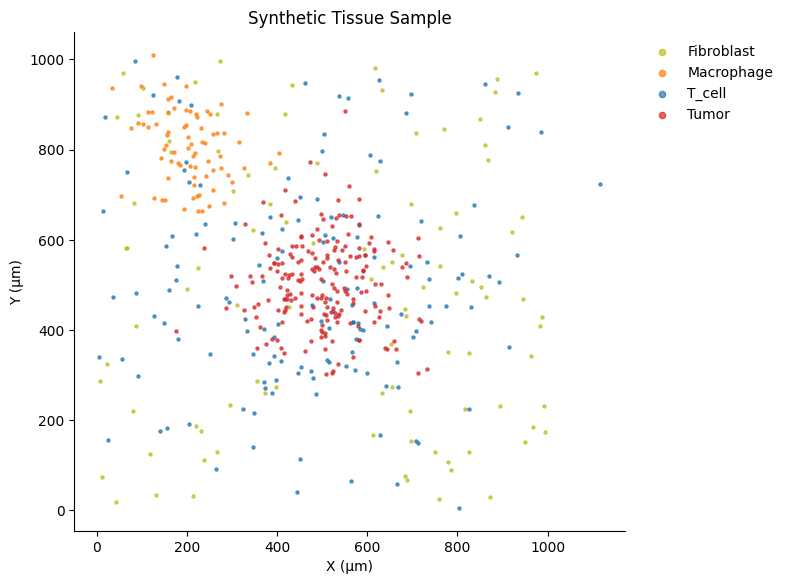

In [3]:
# Visualize the tissue
fig, ax = plt.subplots(figsize=(8, 8))
plot_spatial_scatter(tissue, ax=ax)
ax.set_title('Synthetic Tissue Sample')
plt.tight_layout()
plt.show()

## Section 1: Distance Calculations

### 1.1 Building KD-Trees

KD-trees enable efficient spatial queries. Let's build one and perform nearest neighbor searches:

In [4]:
# Build a KD-tree from coordinates
tree = build_kdtree(tissue.coordinates)
print(f"KD-tree built with {len(tissue.coordinates)} points")

# Query the tree for the 5 nearest neighbors of the first cell
distances, indices = tree.query(tissue.coordinates[0:1], k=5)
print(f"\nNearest 5 neighbors of cell 0:")
print(f"  Indices: {indices[0]}")
print(f"  Distances: {distances[0].round(2)}")

KD-tree built with 525 points

Nearest 5 neighbors of cell 0:
  Indices: [  0 255  93 154 159]
  Distances: [ 0.    5.82  6.95  8.14 17.27]


### 1.2 Pairwise Distances

Compute distances between all pairs of cells (or between two groups):

In [5]:
# Compute all pairwise distances (warning: can be memory intensive for large datasets)
# For demonstration, we'll use a subset
subset_coords = tissue.coordinates[:100]
dist_matrix = pairwise_distances(subset_coords)

print(f"Distance matrix shape: {dist_matrix.shape}")
print(f"Mean pairwise distance: {dist_matrix.mean():.2f} μm")
print(f"Max pairwise distance: {dist_matrix.max():.2f} μm")

Distance matrix shape: (100, 100)
Mean pairwise distance: 164.61 μm
Max pairwise distance: 472.12 μm


### 1.3 Nearest Neighbor Analysis

Find k-nearest neighbors for all cells efficiently:

Nearest neighbor statistics:
  Mean: 260.02 μm
  Median: 255.00 μm
  Std: 150.99 μm


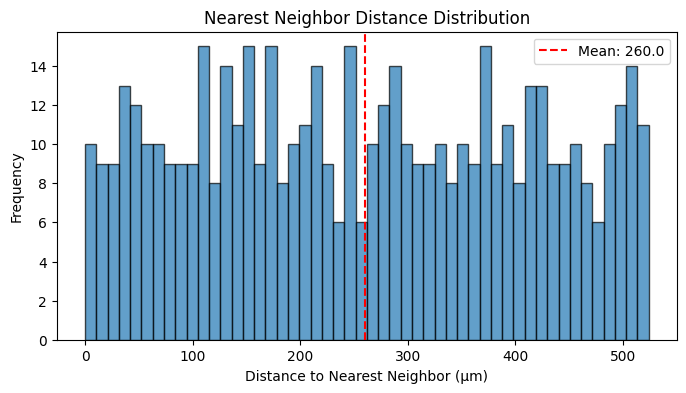

In [6]:
# Find 10 nearest neighbors for each cell
nn_indices, nn_distances = nearest_neighbors(
    tissue.coordinates,
    k=10,
    include_self=False
)

# Analyze nearest neighbor distances
nn1_distances = nn_distances[:, 0]  # First nearest neighbor
print(f"Nearest neighbor statistics:")
print(f"  Mean: {nn1_distances.mean():.2f} μm")
print(f"  Median: {np.median(nn1_distances):.2f} μm")
print(f"  Std: {nn1_distances.std():.2f} μm")

# Plot distribution of nearest neighbor distances
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(nn1_distances, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(nn1_distances.mean(), color='red', linestyle='--', label=f'Mean: {nn1_distances.mean():.1f}')
ax.set_xlabel('Distance to Nearest Neighbor (μm)')
ax.set_ylabel('Frequency')
ax.set_title('Nearest Neighbor Distance Distribution')
ax.legend()
plt.show()

### 1.4 Radius-Based Neighbor Search

Find all neighbors within a specified radius:

Neighbors within 50μm radius:
  Mean: 10.4
  Max: 32
  Min: 0


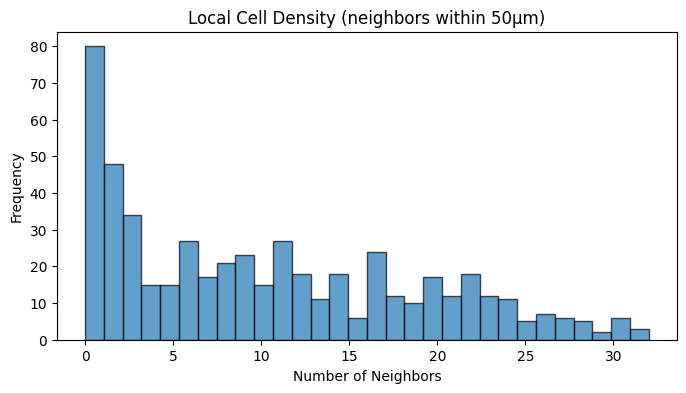

In [7]:
# Find all neighbors within 50 μm radius
neighbors_within_radius = radius_neighbors(
    tissue.coordinates,
    radius=50.0
)

# Count neighbors per cell
neighbor_counts = [len(n) for n in neighbors_within_radius]
print(f"Neighbors within 50μm radius:")
print(f"  Mean: {np.mean(neighbor_counts):.1f}")
print(f"  Max: {np.max(neighbor_counts)}")
print(f"  Min: {np.min(neighbor_counts)}")

# Visualize neighbor count distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(neighbor_counts, bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Neighbors')
ax.set_ylabel('Frequency')
ax.set_title('Local Cell Density (neighbors within 50μm)')
plt.show()

## Section 2: Type-Specific Distance Analysis

### 2.1 Distance to Specific Cell Type

In [8]:
# Compute distance from each cell to nearest tumor cell
dist_to_tumor = distance_to_type(tissue, target_type='Tumor')

# Analyze by cell type
for cell_type in tissue.cell_types_unique:
    mask = tissue.cell_types == cell_type
    mean_dist = dist_to_tumor[mask].mean()
    print(f"{cell_type}: mean distance to tumor = {mean_dist:.1f} μm")

Fibroblast: mean distance to tumor = 173.0 μm
Macrophage: mean distance to tumor = 204.1 μm
T_cell: mean distance to tumor = 94.6 μm
Tumor: mean distance to tumor = 0.0 μm


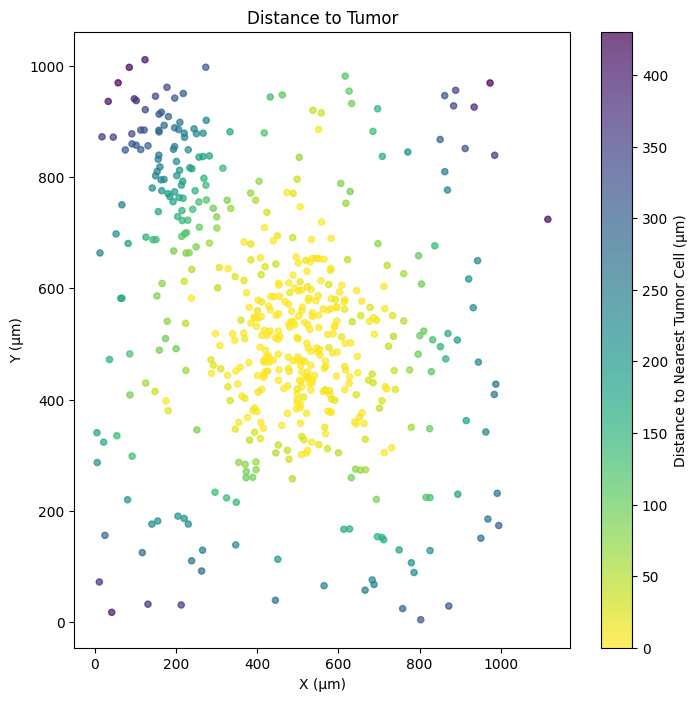

In [9]:
# Visualize distance to tumor
fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    tissue.coordinates[:, 0],
    tissue.coordinates[:, 1],
    c=dist_to_tumor,
    cmap='viridis_r',
    s=20,
    alpha=0.7
)
plt.colorbar(scatter, label='Distance to Nearest Tumor Cell (μm)')
ax.set_xlabel('X (μm)')
ax.set_ylabel('Y (μm)')
ax.set_title('Distance to Tumor')
plt.show()

### 2.2 Distance to Nearest Different Type

In [10]:
# Find distance to nearest cell of a different type
dist_to_different = distance_to_nearest_different_type(tissue)

print("Distance to nearest different cell type:")
for cell_type in tissue.cell_types_unique:
    mask = tissue.cell_types == cell_type
    mean_dist = dist_to_different[mask].mean()
    print(f"  {cell_type}: {mean_dist:.1f} μm")

# This metric indicates how 'isolated' each cell type is

Distance to nearest different cell type:
  Fibroblast: 45.9 μm
  Macrophage: 29.4 μm
  T_cell: 32.8 μm
  Tumor: 22.9 μm


## Section 3: Geometric Properties

In [11]:
# Compute overall centroid
tissue_centroid = centroid(tissue.coordinates)
print(f"Tissue centroid: ({tissue_centroid[0]:.1f}, {tissue_centroid[1]:.1f})")

# Compute centroid for each cell type
centroids = centroid_by_type(tissue)
print("\nCentroids by cell type:")
for cell_type, coord in centroids.items():
    print(f"  {cell_type}: ({coord[0]:.1f}, {coord[1]:.1f})")

# Compute bounding box
bbox = bounding_box(tissue.coordinates)
print(f"\nBounding box: x=[{bbox[0][0]:.1f}, {bbox[0][1]:.1f}], "
      f"y=[{bbox[1][0]:.1f}, {bbox[1][1]:.1f}]")

# Point density
density = point_density(tissue.coordinates)
print(f"\nCell density: {density:.6f} cells/μm²")

Tissue centroid: (457.4, 543.0)

Centroids by cell type:
  Fibroblast: (536.2, 492.0)
  Macrophage: (203.6, 805.8)
  T_cell: (474.2, 497.8)
  Tumor: (500.6, 503.9)

Bounding box: x=[5.7, 4.6], y=[1115.8, 1010.6]

Cell density: 0.000470 cells/μm²


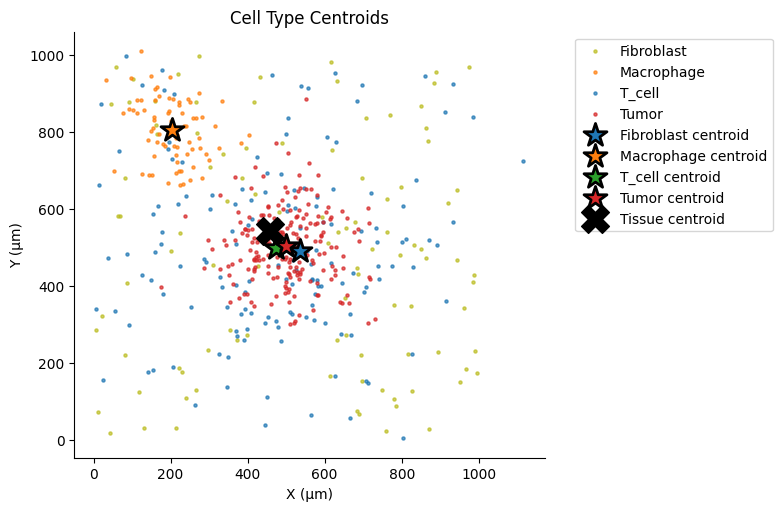

In [12]:
# Visualize centroids
fig, ax = plt.subplots(figsize=(8, 8))
plot_spatial_scatter(tissue, ax=ax)

# Mark centroids
colors = plt.cm.tab10.colors
for i, (cell_type, coord) in enumerate(centroids.items()):
    ax.scatter(coord[0], coord[1], marker='*', s=300, c=[colors[i]], 
               edgecolors='black', linewidths=2, label=f'{cell_type} centroid')

ax.scatter(*tissue_centroid, marker='X', s=400, c='black', label='Tissue centroid')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Cell Type Centroids')
plt.tight_layout()
plt.show()

## Section 4: Spatial Clustering

### 4.1 DBSCAN Clustering

DBSCAN identifies dense regions without requiring the number of clusters:

In [13]:
# Apply DBSCAN clustering
cluster_labels = dbscan_clustering(
    tissue,
    eps=40,  # Maximum distance between neighbors
    min_samples=5  # Minimum cluster size
)

# Count clusters (excluding noise, labeled as -1)
unique_clusters = np.unique(cluster_labels)
n_clusters = len([c for c in unique_clusters if c >= 0])
n_noise = np.sum(cluster_labels == -1)

print(f"DBSCAN Results:")
print(f"  Number of clusters: {n_clusters}")
print(f"  Noise points: {n_noise}")

DBSCAN Results:
  Number of clusters: 4
  Noise points: 161


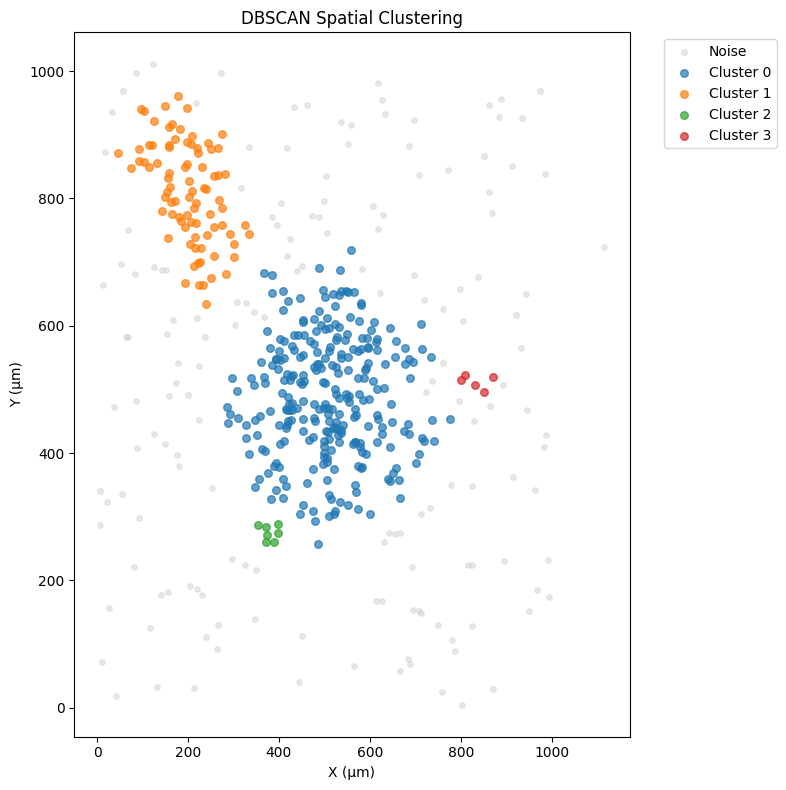

In [14]:
# Visualize DBSCAN clusters
fig, ax = plt.subplots(figsize=(8, 8))

# Plot noise points
noise_mask = cluster_labels == -1
ax.scatter(
    tissue.coordinates[noise_mask, 0],
    tissue.coordinates[noise_mask, 1],
    c='lightgray',
    s=15,
    alpha=0.5,
    label='Noise'
)

# Plot clusters
for cluster_id in [c for c in unique_clusters if c >= 0]:
    mask = cluster_labels == cluster_id
    ax.scatter(
        tissue.coordinates[mask, 0],
        tissue.coordinates[mask, 1],
        s=30,
        alpha=0.7,
        label=f'Cluster {cluster_id}'
    )

ax.set_xlabel('X (μm)')
ax.set_ylabel('Y (μm)')
ax.set_title('DBSCAN Spatial Clustering')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.2 K-Means Spatial Clustering

In [16]:
# Apply k-means clustering
kmeans_labels = kmeans_spatial(tissue, n_clusters=5, random_state=42)

# Get cluster statistics
stats = cluster_statistics(tissue, kmeans_labels)

print("K-means Cluster Statistics:")
for cluster_id, centroid in stats['cluster_centroids'].items():
    print(f"\nCluster {cluster_id}:")
    print(f"  Size: {stats['cluster_sizes'][cluster_id]} cells")
    print(f"  Center: ({centroid[0]:.1f}, {centroid[1]:.1f})")

K-means Cluster Statistics:

Cluster 0:
  Size: 227 cells
  Center: (508.9, 518.9)

Cluster 1:
  Size: 116 cells
  Center: (205.0, 799.1)

Cluster 2:
  Size: 76 cells
  Center: (269.2, 314.9)

Cluster 3:
  Size: 36 cells
  Center: (763.9, 803.8)

Cluster 4:
  Size: 70 cells
  Center: (755.4, 310.4)


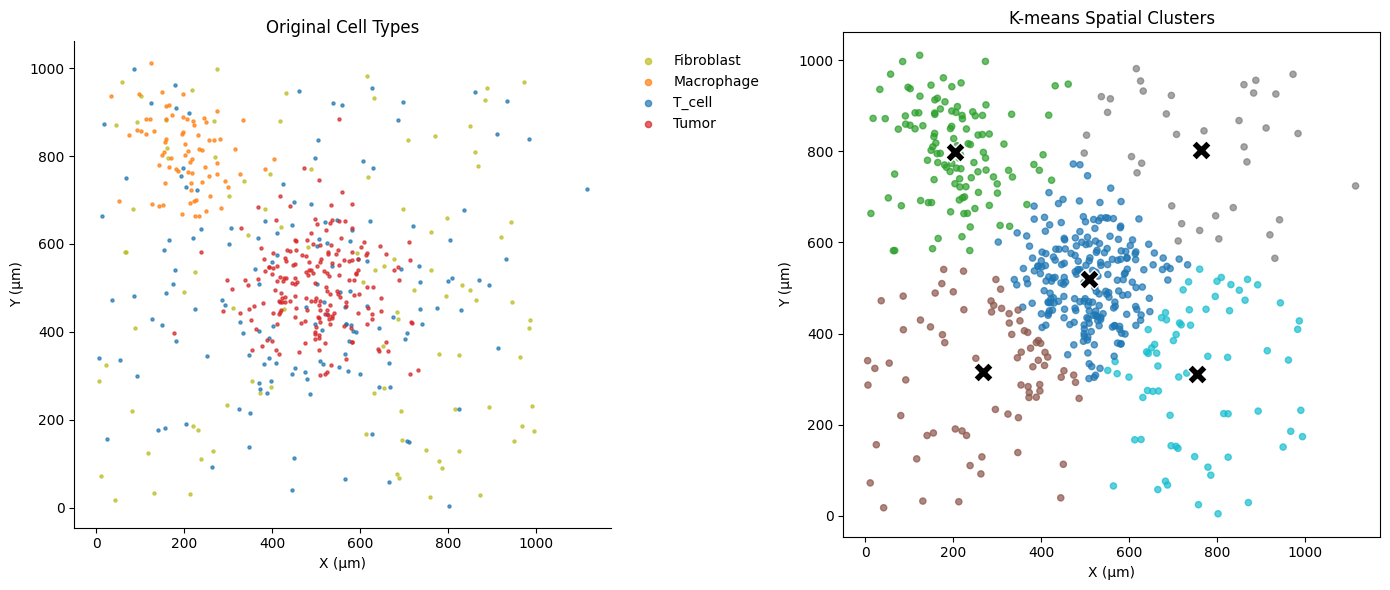

In [17]:
# Visualize k-means clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Original cell types
plot_spatial_scatter(tissue, ax=axes[0])
axes[0].set_title('Original Cell Types')

# Right: K-means clusters
scatter = axes[1].scatter(
    tissue.coordinates[:, 0],
    tissue.coordinates[:, 1],
    c=kmeans_labels,
    cmap='tab10',
    s=20,
    alpha=0.7
)
axes[1].set_xlabel('X (μm)')
axes[1].set_ylabel('Y (μm)')
axes[1].set_title('K-means Spatial Clusters')

# Add cluster centers
for cluster_id, centroid in stats['cluster_centroids'].items():
    axes[1].scatter(*centroid, marker='X', s=200, c='black', edgecolors='white')

plt.tight_layout()
plt.show()

### 4.3 Connected Components

Find spatially connected groups of cells:

In [18]:
connected_components_spatial?

Signature:
connected_components_spatial(
    data: "'SpatialTissueData'",
    radius: 'float',
    cell_types: 'Optional[List[str]]' = None,
) -> 'np.ndarray'
Docstring:
Find connected components based on spatial proximity.

Parameters
----------
data : SpatialTissueData
    Spatial tissue data.
radius : float
    Maximum distance for connectivity.
cell_types : list of str, optional
    Only consider these cell types.

Returns
-------
np.ndarray
    Component labels.
File:      ~/miniforge3/envs/spatialtissue-tutorials/lib/python3.10/site-packages/spatialtissuepy/spatial/clustering.py
Type:      function

In [19]:
# Find connected components (cells connected within 30μm)
component_labels = connected_components_spatial(tissue, radius=30)

n_components = len(np.unique(component_labels))
print(f"Number of connected components: {n_components}")

# Size of each component
component_sizes = [np.sum(component_labels == i) for i in np.unique(component_labels)]
print(f"Largest component: {max(component_sizes)} cells")
print(f"Smallest component: {min(component_sizes)} cells")

ValueError: 'radius' is not a valid GraphMethod

## Exercise: Analyze Your Own Patterns

Try the following:

1. **Vary DBSCAN parameters:** Try different `eps` (30, 50, 70) and `min_samples` (3, 5, 10) values. How do the clusters change?

2. **Compare cell type isolation:** Which cell type has the largest mean distance to other types? What does this suggest about tissue organization?

3. **Find dense regions:** Identify cells with the most neighbors within 50μm. What cell types dominate these dense regions?

In [ ]:
# Your code here


## Summary

In this tutorial, you learned:

- **Distance calculations:** Using KD-trees for efficient nearest neighbor queries and pairwise distances
- **Type-specific analysis:** Measuring distances between specific cell populations
- **Geometric properties:** Computing centroids, bounding boxes, and densities
- **Spatial clustering:** Applying DBSCAN and k-means to identify spatial regions
- **Connected components:** Finding groups of spatially connected cells

These operations form the foundation for more advanced spatial statistics.

## Next Steps

- **Tutorial 4: Spatial Statistics** - Learn Ripley's K, colocalization, and hotspot detection
- **Tutorial 5: Neighborhoods** - Deep dive into neighborhood composition analysis